Parameters

In [1]:
import re
import sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

import scipy

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- Directory containing lfads_output_*.h5 (written by run_posterior_sampling at the
#     end of 2_run_pbt_kcEXP00H.py, inside the run's best_model/ folder). ---
# Leave as None to auto-pick the most recent run; or set explicitly to a best_model dir.
H5_DIR = None
if H5_DIR is None:
    # cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, "No best_model with lfads_output_*.h5 found under ../runs"
    H5_DIR = cands[-1]
H5_DIR = Path(H5_DIR)
print("Using LFADS outputs from:", H5_DIR)

# --- Source xarray (.nc) files: needed only for per-trial condition labels (PSTHs / colors) ---
XARRAY_DIR = (
    '../datasets/xarray_files/'
)

# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202607161710/pbt/kcEXP00H_multisession_KC1pt2/260716/best_model


## Load lfads outputs

In [2]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged = np.full((n_samples, *train_data.shape[1:]), np.nan, dtype=train_data.dtype)
    merged[train_inds] = train_data
    merged[valid_inds] = valid_data
    return merged

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f"No lfads_output_*.h5 in {H5_DIR}"

factors = {}
predicted_ts = {} #analogous to rates in tutorial


### claude gen below
flies = []                # h5 stems, one per fly
train_inds, valid_inds = {},{}
observed_ts, predicted_ts, factors = {}, {}, {}     # merged (n_trials, n_frames_per_trial, .) in original trial order
split = {}                # 'train'/'valid' arrays for the held-out R^2 metric
for path in h5_paths:
    fly = Path(path).stem.replace('lfads_output_lfads_', '')
    flies.append(fly)
    with h5py.File(path) as f:
        train_inds[fly] = f['train_inds'][()].astype(int) #training trial indices 
        valid_inds[fly] = f['valid_inds'][()].astype(int) #validation trial indices
        observed_ts[fly]   = merge_train_valid(f['train_recon_data'][()],
                                         f['valid_recon_data'][()],train_inds[fly], valid_inds[fly] )
        predicted_ts[fly]    = merge_train_valid(f['train_output_params'][()],
                                         f['valid_output_params'][()], train_inds[fly], valid_inds[fly] )
        factors[fly] = merge_train_valid(f['train_factors'][()],
                                         f['valid_factors'][()], train_inds[fly], valid_inds[fly] )
        # split[fly] = dict(
        #     train=(observed_ts[trf['train_recon_data'][()], f['train_output_params'][()]),
        #     valid=(f['valid_recon_data'][()], f['valid_output_params'][()]),
        # )
    print(f"  {fly}: observed_ts/pred {observed_ts[fly].shape}, factors {factors[fly].shape}")

n_fac = next(iter(factors.values())).shape[-1]
n_frames_per_trial = next(iter(factors.values())).shape[1]
print(f"\n{len(flies)} flies | n_factors = {n_fac} | n_frames_per_trial = {n_frames_per_trial}")

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 66), factors (16, 1050, 50)
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)

5 flies | n_factors = 50 | n_frames_per_trial = 1050


#### understand variables

In [3]:
f=h5py.File(h5_paths[0])
fly_orig_data=f['train_output_params'][()]
fly_recon_data=f['train_recon_data'][()]

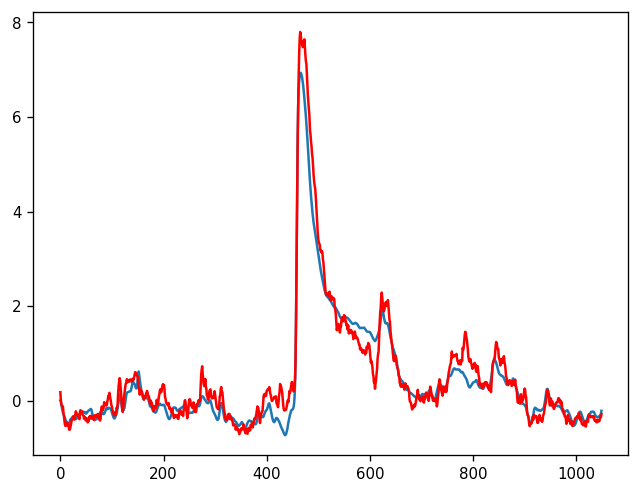

In [4]:
import matplotlib.pyplot as plt
plt.plot(fly_orig_data[0,:,3]) 
plt.plot(fly_recon_data[0,:,3],'r')
plt.show()

In [5]:
f.keys()

<KeysViewHDF5 ['readin_weight', 'readout_bias', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data', 'zscore_mean', 'zscore_std']>

## remove baseline trials

In [12]:
import xarray as xr

# condition labels keyed by .nc filename stem (e.g. 'H30003-005_..._DVAP')
cond_by_ncstem = {}
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    print(p)
    with xr.open_dataset(p) as ds:
        cond_by_ncstem[Path(p).stem] = \
            np.asarray(ds['condition'].values).reshape(-1).astype(str)


../datasets/xarray_files/H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc


In [13]:
BASELINE_TRIALS=[0,9]
conditions = {}   # fly -> (n_trials,) str
for fly_name in flies:
    num_kept_trials = observed_ts[fly_name].shape[0]
    conditions_from_xarray = cond_by_ncstem[fly_name]
    if len(conditions_from_xarray) == num_kept_trials + len(BASELINE_TRIALS):
        conditions[fly_name] = np.delete(conditions_from_xarray, BASELINE_TRIALS)
    else:
        conditions[fly_name] = conditions_from_xarray


### 1. Model Performance
Train R^2 = how well model fit the training data

In [14]:
import pandas as pd

def r2(y, yhat):
    y = y.reshape(-1); yhat = yhat.reshape(-1)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

In [15]:
r2train_flies={}
r2valid_flies={}
for fly in flies:
    obs= observed_ts[fly][train_inds[fly]]
    pred= predicted_ts[fly][train_inds[fly]]
    r2train_flies[fly] = r2(obs,pred)

    obs= observed_ts[fly][valid_inds[fly]]
    pred= predicted_ts[fly][valid_inds[fly]]
    r2valid_flies[fly] = r2(obs,pred)

# Compact fly labels for plotting (e.g. 'H30003-005')
def _short(fly):
    m = re.search(r'H\d+-\d+', fly)
    return m.group() if m else fly
short = {fly: _short(fly) for fly in flies}
short


{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H30003-005',
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H34006-007',
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H35005-006',
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H36006-007',
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H37003-004'}

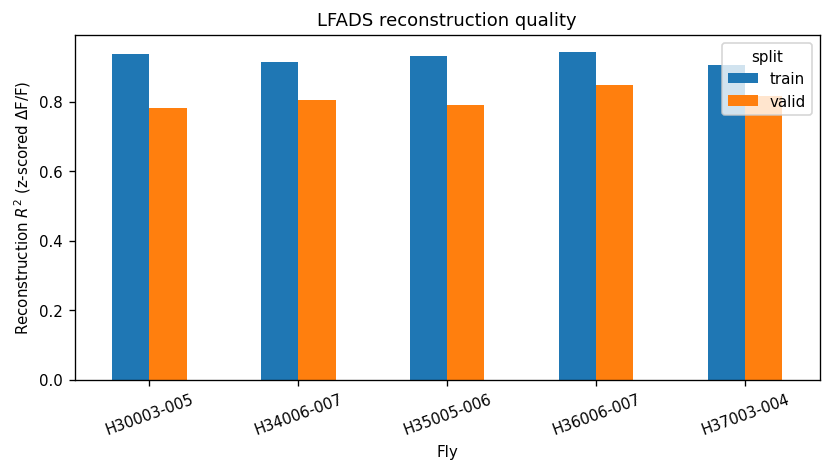

    fly_short  train  valid
0  H30003-005  0.937  0.781
1  H34006-007  0.913  0.804
2  H35005-006  0.932  0.790
3  H36006-007  0.943  0.847
4  H37003-004  0.907  0.816

Mean train R2 = 0.926 | mean valid R2 = 0.807


In [16]:
import pandas as pd
#create dataframe w/ train & valid as two columns then plot barplot

r2_df = (pd.DataFrame({'train': r2train_flies, 'valid': r2valid_flies})
        .rename_axis('fly').reset_index())
r2_df['fly_short'] = r2_df['fly'].map(short)

ax = r2_df.plot.bar(figsize=(7, 4), rot=20)
ax.set_xlabel('Fly'); ax.set_ylabel('Reconstruction $R^2$ (z-scored ΔF/F)')
ax.set_title('LFADS reconstruction quality')
ax.set_xticklabels(r2_df['fly_short'] )
ax.legend(title='split')
plt.tight_layout(); plt.show()

print(r2_df[["fly_short","train","valid"]].round(3))
print("\nMean train R2 = {:.3f} | mean valid R2 = {:.3f}".format(
    r2_df['train'].mean(), r2_df['valid'].mean()))



## 2-- visualize obs vs predicted TS

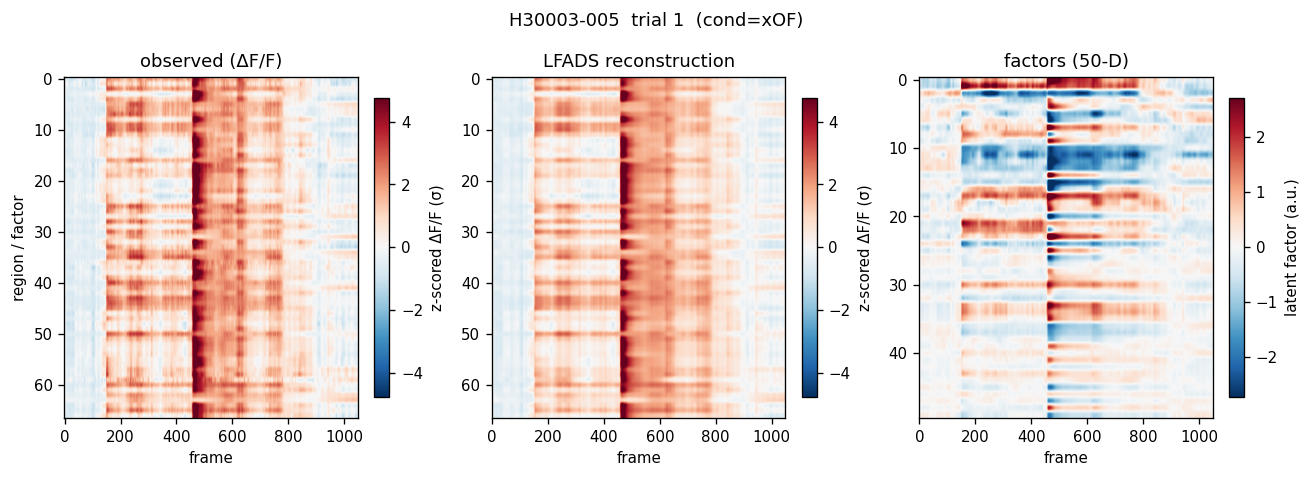

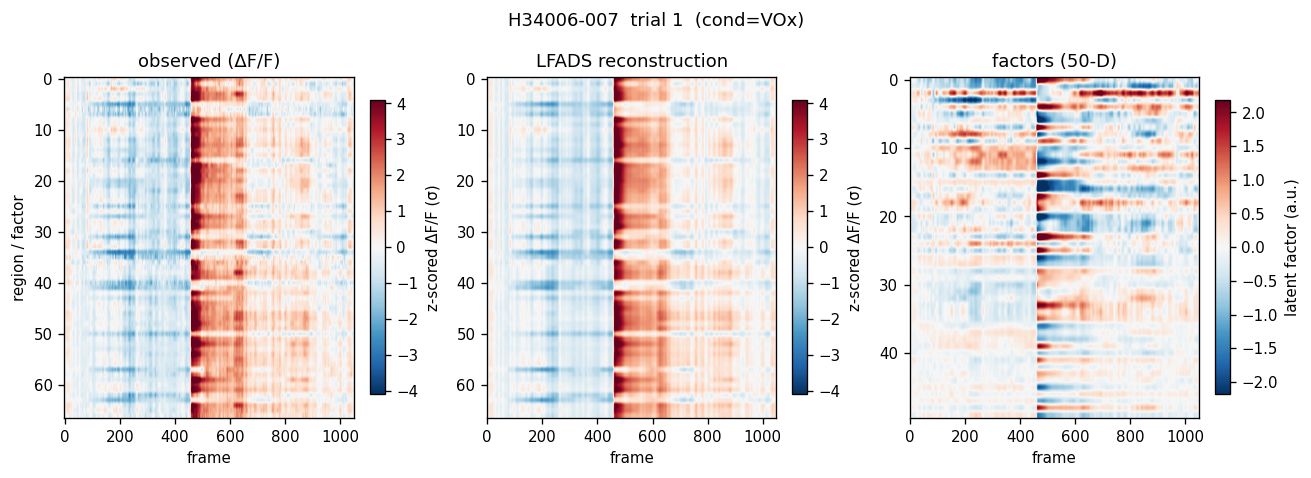

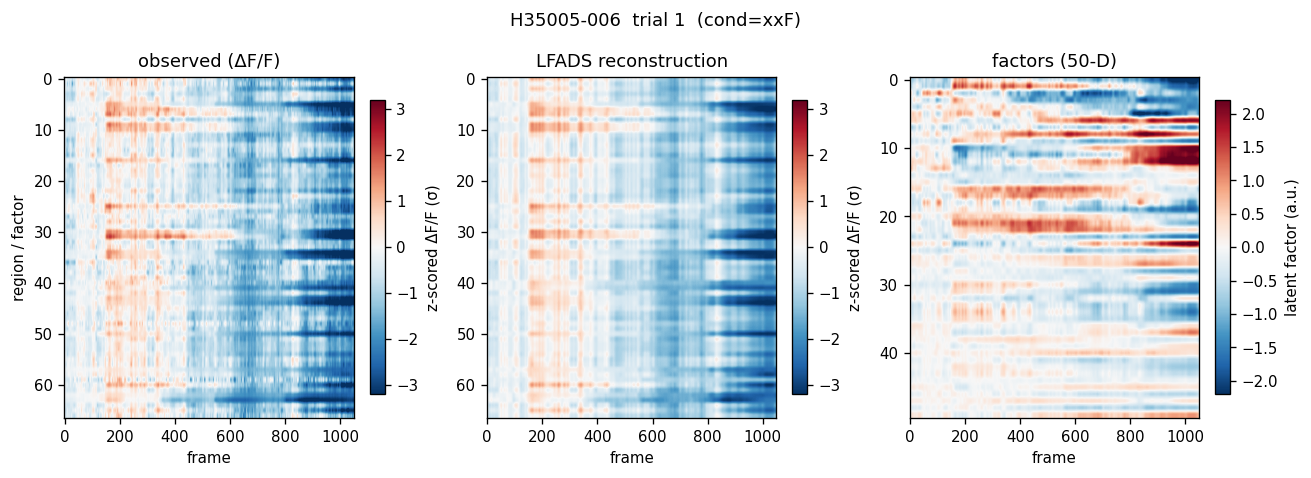

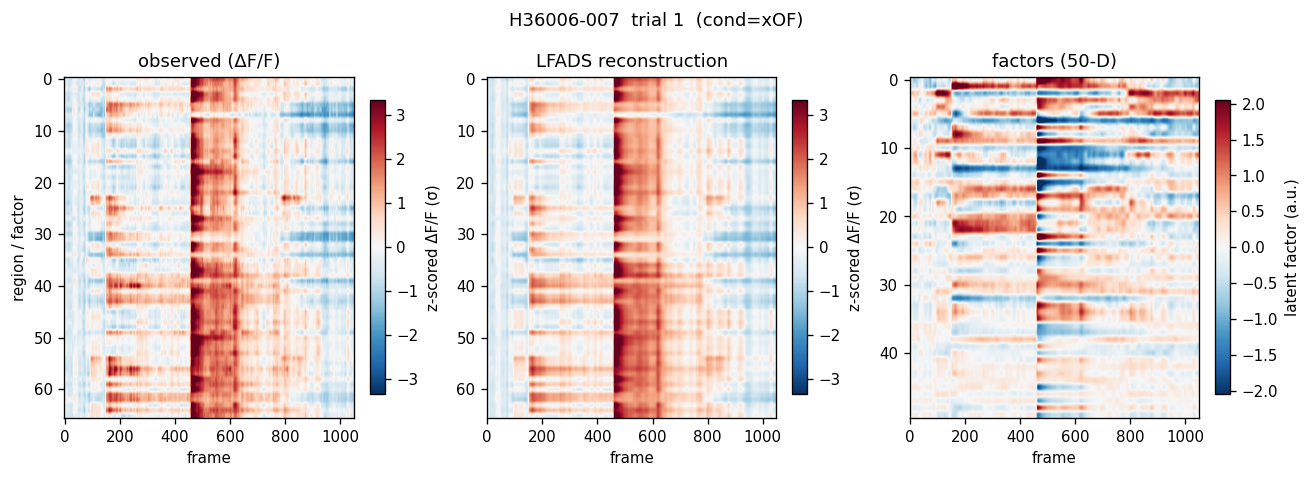

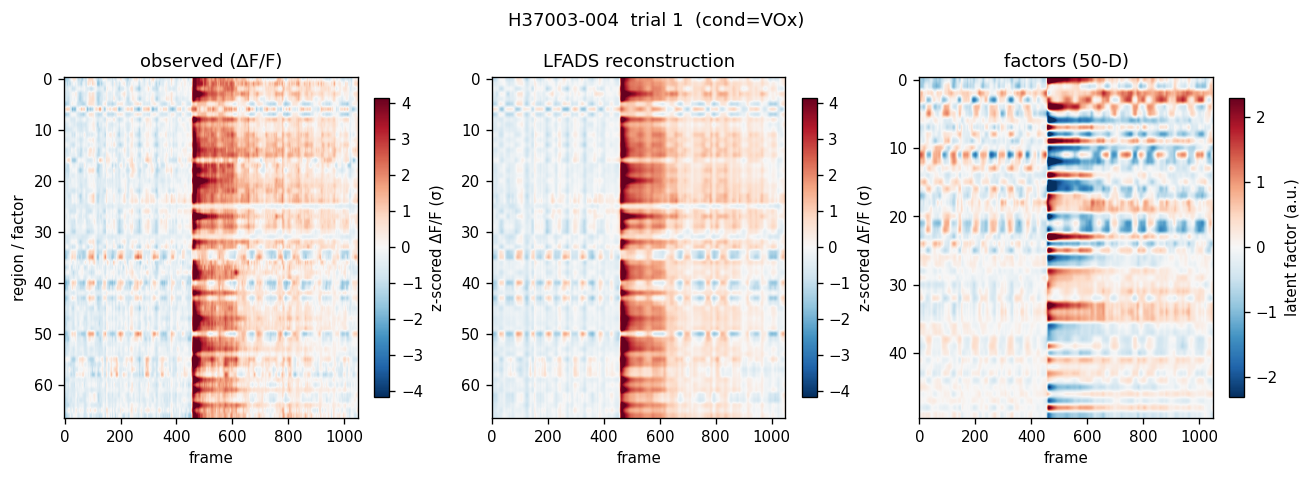

In [17]:
fly = flies[4]
trial = 1

for fly in flies:
    # (array, kind) — kind sets the colorbar range/label. observed & reconstruction share the
    # z-scored ΔF/F range; factors are unitless latent activations with their own range.
    panels = {
        'observed (ΔF/F)':       (observed_ts[fly][trial],   'dff'),
        'LFADS reconstruction':  (predicted_ts[fly][trial],    'dff'),
        f'factors ({n_fac}-D)':  (factors[fly][trial], 'fac'),
    }
    # shared symmetric range for the two ΔF/F panels; separate range for factors
    dff_vmax = np.nanpercentile(np.abs(np.concatenate([observed_ts[fly][trial], predicted_ts[fly][trial]])), 99)
    cbar_label = {'dff': 'z-scored ΔF/F (σ)', 'fac': 'latent factor (a.u.)'}

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    for ax, (name, (arr, kind)) in zip(axes, panels.items()):
        vmax = dff_vmax if kind == 'dff' else np.nanpercentile(np.abs(arr), 99)
        im = ax.imshow(arr.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(name); ax.set_xlabel('frame')
        fig.colorbar(im, ax=ax, fraction=0.046, label=cbar_label[kind])
    axes[0].set_ylabel('region / factor')
    fig.suptitle(f'{short[fly]}  trial {trial}  (cond={conditions[fly][trial]})')
    plt.tight_layout(); plt.show()


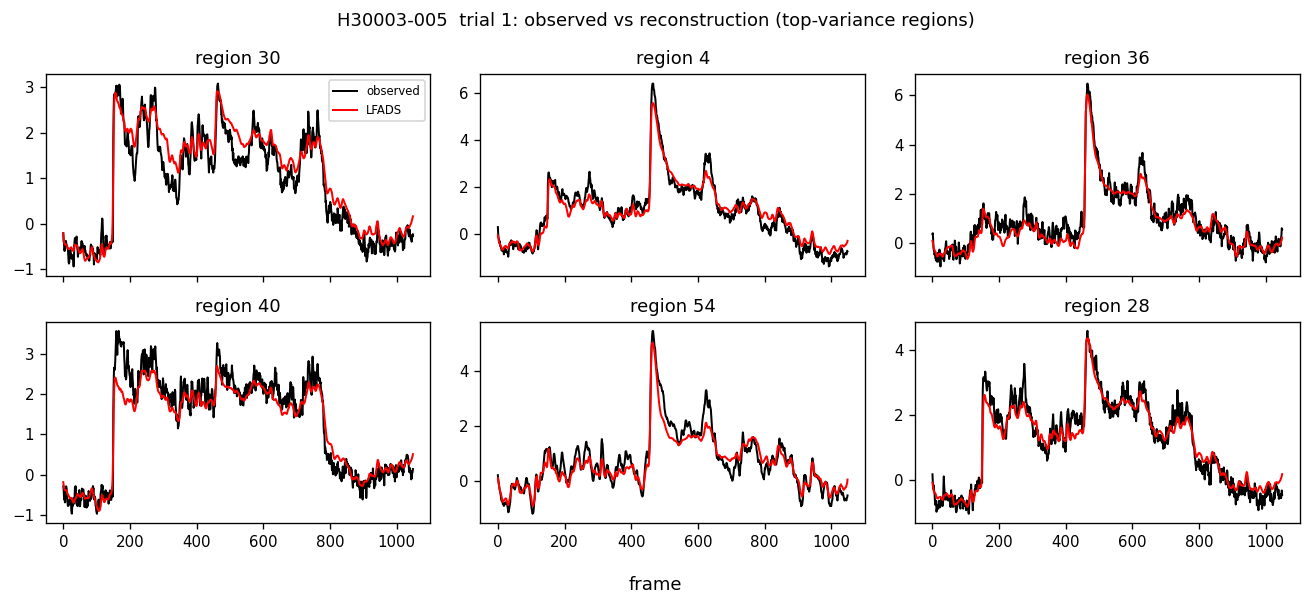

In [18]:
# Region-trace overlay: highest-variance regions for this fly
fly = flies[0]
trial=1
reg_var = observed_ts[fly].reshape(-1, observed_ts[fly].shape[-1]).var(0)
regs = np.argsort(reg_var)[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True)
for ax, r in zip(axes.flatten(), regs):
    ax.plot(observed_ts[fly][trial, :, r], 'k', lw=1.2, label='observed')
    ax.plot(predicted_ts[fly][trial, :, r], 'r', lw=1.2, label='LFADS')
    ax.set_title(f'region {r}')
axes[0, 0].legend(fontsize=7)
fig.suptitle(f'{short[fly]}  trial {trial}: observed vs reconstruction (top-variance regions)')
fig.supxlabel('frame'); plt.tight_layout(); plt.show()

## 3.1 — Latent state-space

One PCA fit across **all flies' factors**, then per-fly 3-D trajectories colored by stimulus
condition (parallel to the Rouse tutorial's reach-direction trajectories). If the multisession
model found a **shared, fly-invariant** latent code, the per-fly subplots look alike and the same
condition occupies the same region of factor space across flies.

explained variance (PC1-3): [0.501 0.137 0.105]  sum = 0.743


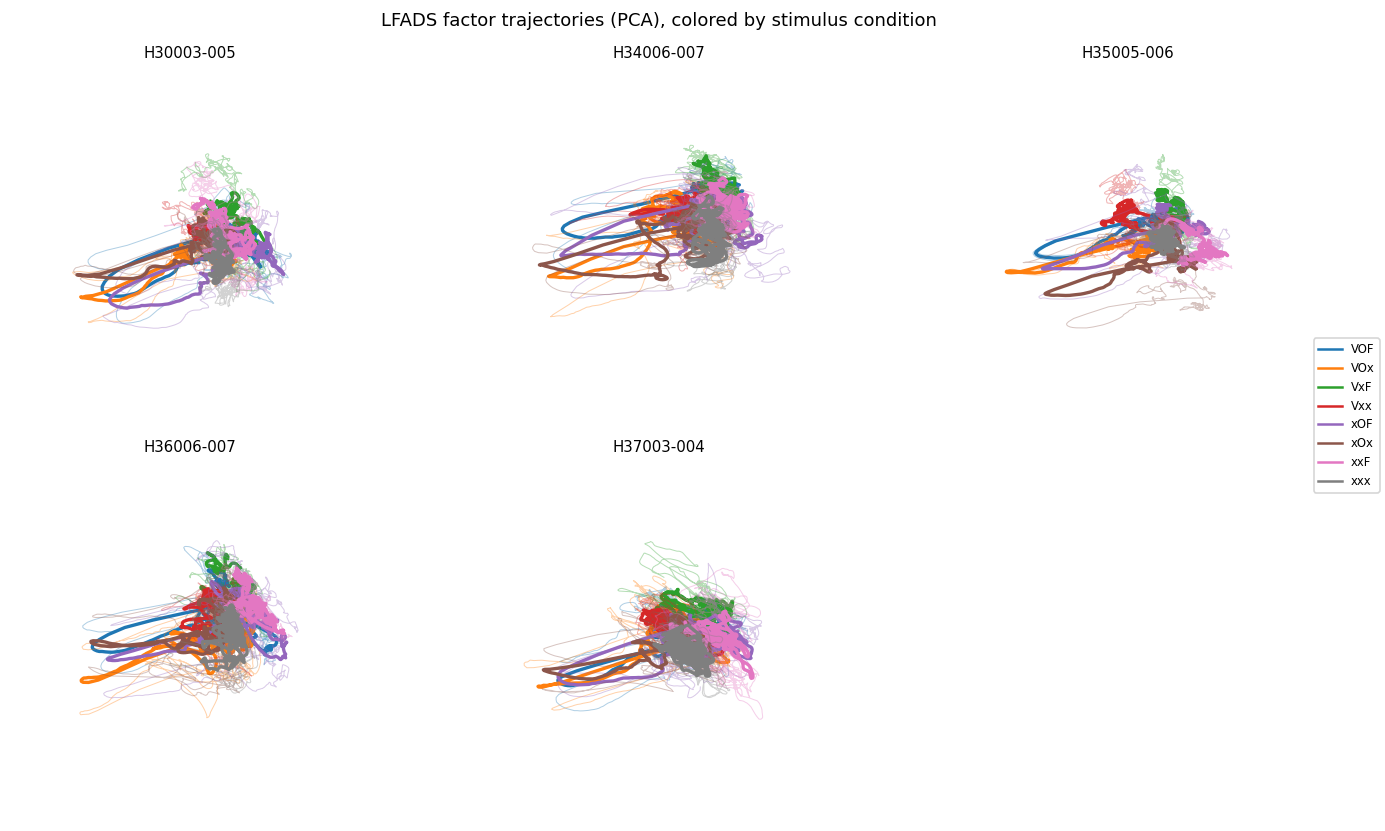

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import cm
# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

# Fit one PCA + scaler on all factors pooled across flies
all_fac = np.concatenate([factors[f].reshape(-1, n_fac) for f in flies], 0)
ss = StandardScaler().fit(all_fac)
pca = PCA(n_components=3).fit(ss.transform(all_fac))
print("explained variance (PC1-3):", np.round(pca.explained_variance_ratio_, 3),
      " sum =", round(pca.explained_variance_ratio_[:3].sum(), 3))

colors = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
ncol = min(len(flies), 3)
nrow = int(np.ceil(len(flies) / ncol))
fig = plt.figure(figsize=(4 * ncol, 3.5 * nrow))
for i, fly in enumerate(flies):
    ax = fig.add_subplot(nrow, ncol, i + 1, projection='3d')
    f3 = pca.transform(ss.transform(factors[fly].reshape(-1, n_fac)))
    f3 = f3.reshape(factors[fly].shape[0], n_frames_per_trial, 3)
    conds = conditions[fly]
    for c in [c for c in COND_ORDER if (conds == c).any()]:
        for tr in np.where(conds == c)[0]:
            ax.plot(*f3[tr].T, color=colors[c], alpha=0.35, lw=0.6)
        ax.plot(*f3[conds == c].mean(0).T, color=colors[c], lw=2)
    ax.set_title(short[fly], fontsize=9); ax.axis('off')
    ax.view_init(elev=15., azim=37.5)
handles = [plt.Line2D([], [], color=colors[c], label=c)
           for c in COND_ORDER]
fig.legend(handles=handles, loc='center right', fontsize=7, ncol=1)
fig.suptitle('LFADS factor trajectories (PCA), colored by stimulus condition')
plt.tight_layout(); plt.show()

### 3.2 visualize latents

In [20]:
stim_colors = {'odor': 'tab:green', 'walk': 'tab:orange', 'vision': 'tab:purple'}
cond_cmap = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
cond_cmap

{'VOF': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 'VOx': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 'VxF': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 'Vxx': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 'xOF': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 'xOx': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0),
 'xxF': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0),
 'xxx': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0)}

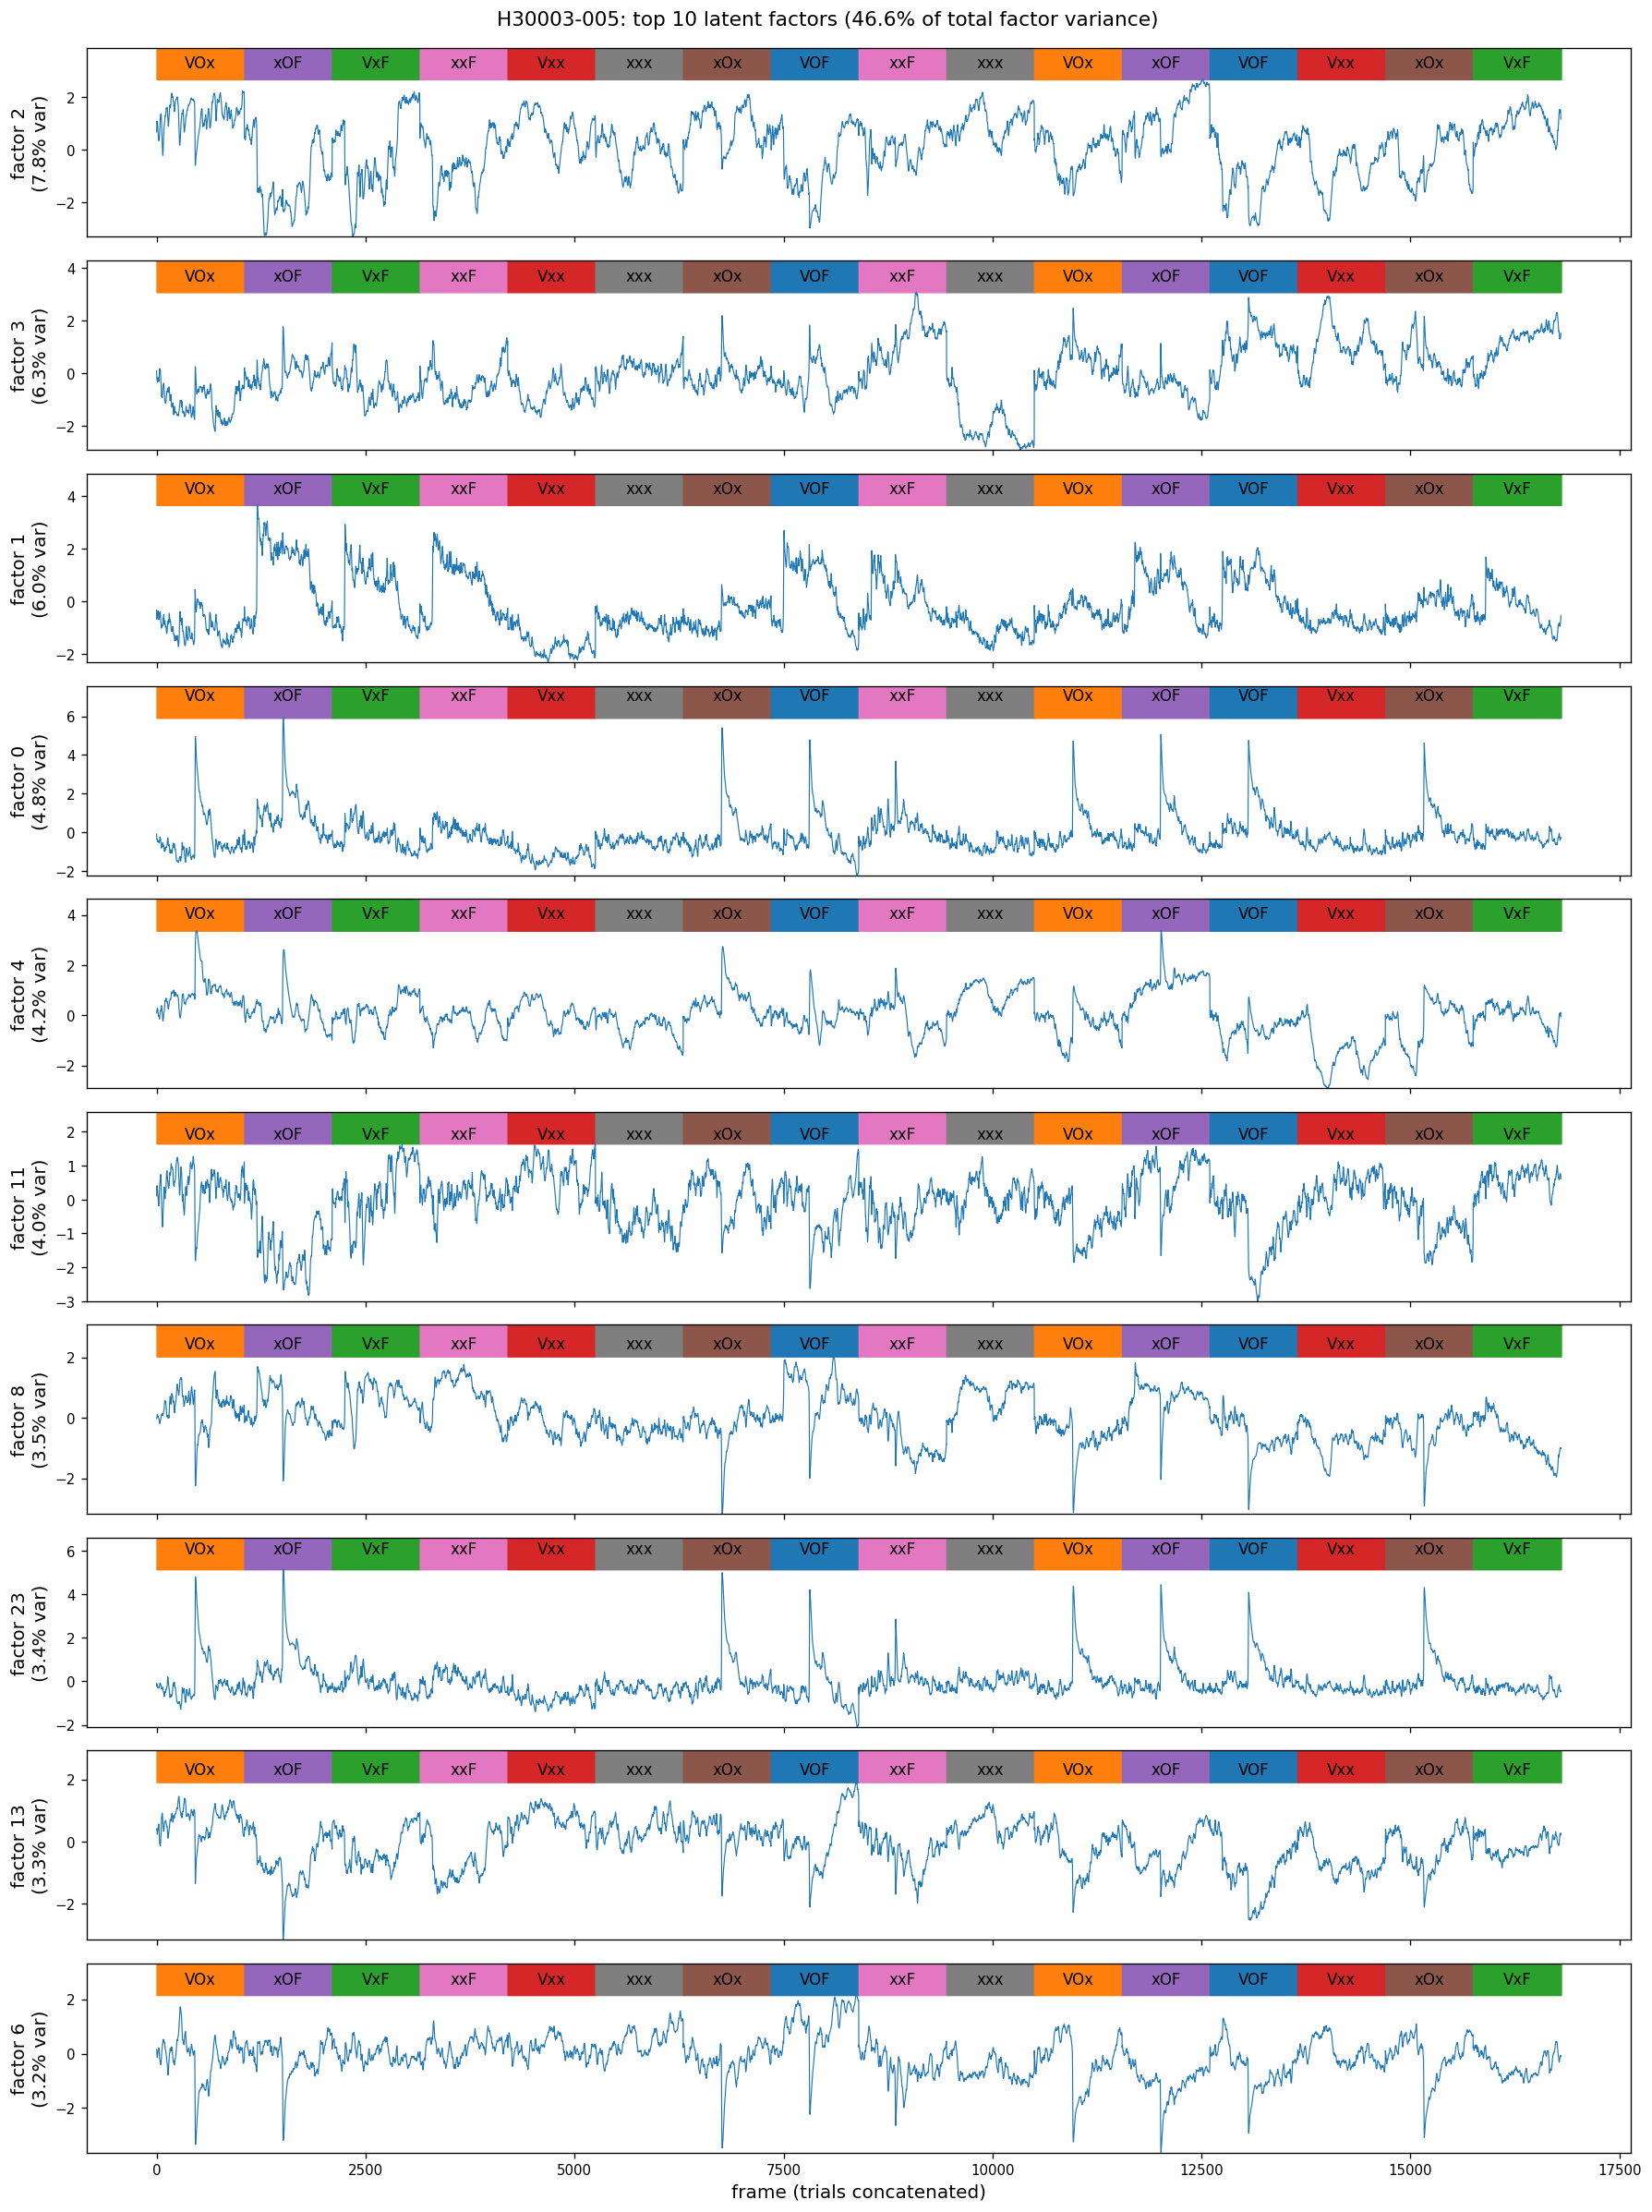

In [21]:
fly='H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP'
factor = factors[fly]

n_trials = conditions[fly].shape[0]
x = np.arange(n_trials*n_frames_per_trial)
smask = {i: (x >= i*n_frames_per_trial) & (x < (i+1)*n_frames_per_trial)
         for i in range(n_trials)}  # one boolean mask per trial for the condition color bars

n_show = 10
fac_var = factor.reshape(-1, n_fac).var(0) #collapses trials and frames into one axis numTrials*numFrames,50.var(0)
frac_var = fac_var / fac_var.sum()          # share of total factor variance
top_fac = np.argsort(fac_var)[::-1][:n_show]  # top 10 latents by variance

fig, axes = plt.subplots(n_show, 1, figsize=(15, 2*n_show), sharex=True)
for ax, i_fac in zip(axes, top_fac):
    flat_factor = factor[:,:,i_fac].flatten() #flatten all trials into one long expt for plotting
    ax.plot(flat_factor, lw=0.7)
    lo, hi = flat_factor.min(), flat_factor.max()
    ylim = [hi, hi + 0.2*(hi-lo)]  # color bar sits just above the trace
    for i_condition in range(len(conditions[fly])):
        condition = conditions[fly][i_condition]
        ax.fill_between(x, ylim[0], ylim[1], where=smask[i_condition], color=cond_cmap[condition])
    ax.set_ylim(lo, ylim[1])
    ax.set_ylabel(f'factor {i_fac}\n({100*frac_var[i_fac]:.1f}% var)',fontsize=12)
    for i_condition in range(len(conditions[fly])):
        ax.text((i_condition + 0.5) * n_frames_per_trial, ax.get_ylim()[1]-0.9,
                    conditions[fly][i_condition], ha='center', va='bottom',
                    fontsize=10, rotation=0) #adds condition text labels above the top subplot
# for i_condition in range(len(conditions[fly])):
#     axes[0].text((i_condition + 0.5) * n_frames_per_trial, axes[0].get_ylim()[1]-0.9,
#                  conditions[fly][i_condition], ha='center', va='bottom',
#                  fontsize=10, rotation=0) #adds condition text labels above the top subplot

axes[-1].set_xlabel('frame (trials concatenated)',fontsize=12)
fig.suptitle(f'{short[fly]}: top {n_show} latent factors '
             f'({100*frac_var[top_fac].sum():.1f}% of total factor variance)', y=0.995, fontsize=13)
plt.tight_layout(); plt.show()

## load data xarrays


## factor correlation to stimuli features

In [22]:
ds= xr.load_dataset(list(Path(XARRAY_DIR).glob('*.nc'))[0])

In [23]:
fly='H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP'
factor = factors[fly]

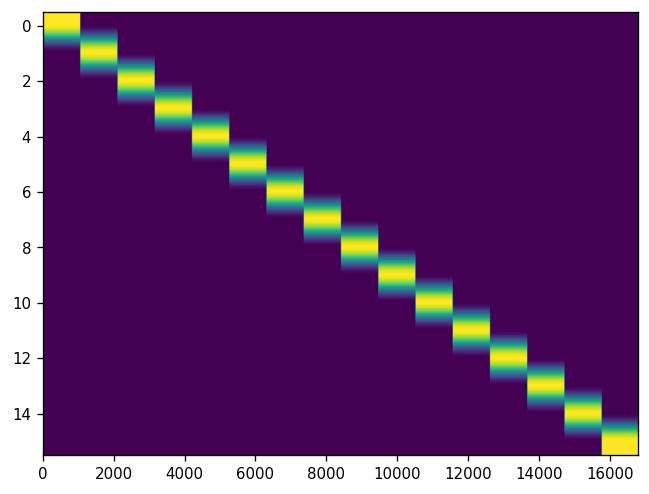

In [24]:
plt.imshow(list(smask.values()),aspect="auto")


In [25]:
condition_vector = dict()

for i_condition, condition in enumerate(conditions[fly]):
    print(i_condition, condition)
    condition_vector[condition] = np.zeros(16800)

for i, condition1 in enumerate(conditions[fly]):
    for condition2 in condition_vector.keys():
    #for i in range(n_trials):
        if condition1 == condition2:
            condition_vector[condition1] += (x >= i*n_frames_per_trial) & (x < (i+1)*n_frames_per_trial)

condition_vector

0 VOx
1 xOF
2 VxF
3 xxF
4 Vxx
5 xxx
6 xOx
7 VOF
8 xxF
9 xxx
10 VOx
11 xOF
12 VOF
13 Vxx
14 xOx
15 VxF


{'VOx': array([1., 1., 1., ..., 0., 0., 0.]),
 'xOF': array([0., 0., 0., ..., 0., 0., 0.]),
 'VxF': array([0., 0., 0., ..., 1., 1., 1.]),
 'xxF': array([0., 0., 0., ..., 0., 0., 0.]),
 'Vxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xOx': array([0., 0., 0., ..., 0., 0., 0.]),
 'VOF': array([0., 0., 0., ..., 0., 0., 0.])}

([<matplotlib.axis.YTick at 0x7620d9e9f130>,
 [Text(0, 0, 'VOx'),
  Text(0, 1, 'xOF'),
  Text(0, 2, 'VxF'),
  Text(0, 3, 'xxF'),
  Text(0, 4, 'Vxx'),
  Text(0, 5, 'xxx'),
  Text(0, 6, 'xOx'),
  Text(0, 7, 'VOF')])

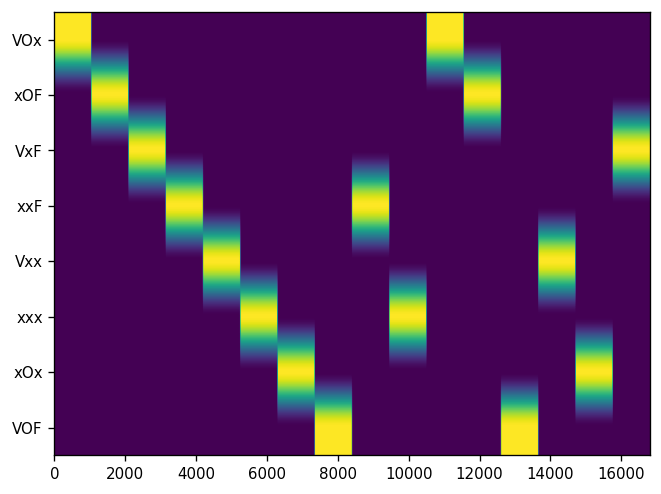

In [26]:
plt.imshow(list(condition_vector.values()), aspect='auto')
plt.yticks(np.arange(len(condition_vector)), list(condition_vector.keys()))

#### Check association of a single factor to each condition

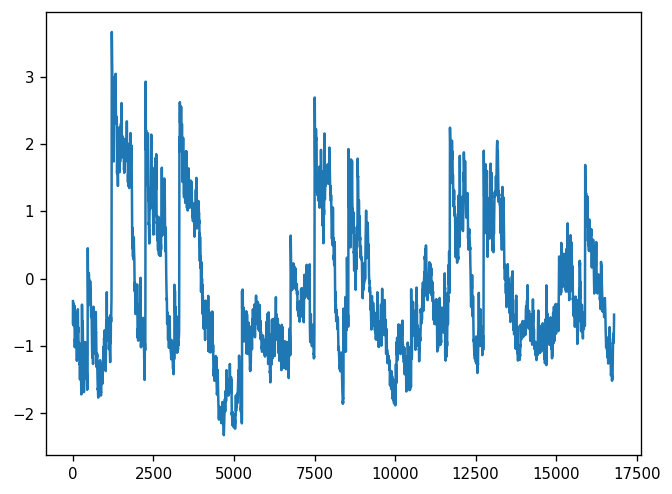

In [27]:
i_fac = 1
flat_factor = factor[:,:,i_fac].flatten()
plt.plot(flat_factor)

In [28]:
pearson_r_p = dict()

for cond in condition_vector.keys():
    pearson_r_p[cond]= scipy.stats.pearsonr(condition_vector[cond],flat_factor)
    pearson_r_p

pearson_r_p

{'VOx': PearsonRResult(statistic=-0.1905127495257291, pvalue=4.517394677673909e-137),
 'xOF': PearsonRResult(statistic=0.34043771916476495, pvalue=0.0),
 'VxF': PearsonRResult(statistic=0.09605924114238215, pvalue=9.764194130719808e-36),
 'xxF': PearsonRResult(statistic=0.2197484303030546, pvalue=8.122414799957002e-183),
 'Vxx': PearsonRResult(statistic=-0.36627786409166535, pvalue=0.0),
 'xxx': PearsonRResult(statistic=-0.27095700657791805, pvalue=1.63981879756202e-280),
 'xOx': PearsonRResult(statistic=-0.07181718413039281, pvalue=1.1643477970226188e-20),
 'VOF': PearsonRResult(statistic=0.2433194137155037, pvalue=6.163091296388478e-225)}

In [29]:
df = pd.DataFrame(
    [
        (cond, *scipy.stats.pearsonr(vec, flat_factor))
        for cond, vec in condition_vector.items()
    ],
    columns=["condition", "r", "p"]
)
df

,condition,r,p
0,VOx,-0.190513,4.517395e-137
1,xOF,0.340438,0.000000e+00
2,VxF,0.096059,9.764194e-36
3,xxF,0.219748,8.122415e-183
4,Vxx,-0.366278,0.000000e+00
5,xxx,-0.270957,1.639819e-280
6,xOx,-0.071817,1.164348e-20
7,VOF,0.243319,6.163091e-225


#### Check association of a all top 10 factors to all conditions

In [30]:
rows = []
for i_fac in top_fac:
    ff = factor[:, :, i_fac].flatten()
    for cond in condition_vector.keys():
        r, p = scipy.stats.pearsonr(condition_vector[cond],ff)
        rows.append({"factor": i_fac, "condition": cond, "r": r, "p": p})

df = pd.DataFrame(rows)
r_matrix = df.pivot(index="condition", columns="factor", values="r")
r_matrix

factor,0,1,2,3,4,6,8,11,13,23
condition,,,,,,,,,,
VOF,0.106750,0.243319,-0.252482,0.125941,-0.138526,0.172175,0.052016,-0.211458,-0.140923,0.021493
VOx,-0.006524,-0.190513,0.141718,-0.109906,0.110821,-0.044024,-0.051108,-0.018250,0.148818,0.067932
VxF,-0.041939,0.096059,0.101135,0.115858,0.033812,-0.050878,0.002439,0.228477,-0.038423,-0.107988
Vxx,-0.318179,-0.366278,-0.031042,0.067418,-0.313001,0.129006,-0.204804,0.275547,0.077478,-0.260246
xOF,0.238092,0.340438,-0.027810,-0.101809,0.281159,-0.212650,0.227651,-0.116965,-0.194915,0.197784
xOx,0.095213,-0.071817,0.063070,0.063126,0.036479,-0.031993,-0.137512,-0.086767,0.055318,0.122017
xxF,0.090455,0.219748,-0.093668,0.153080,-0.089663,0.014365,0.018212,-0.001160,-0.171052,0.025413
xxx,-0.163868,-0.270957,0.099078,-0.313708,0.078920,0.023999,0.093106,-0.069423,0.263699,-0.066404


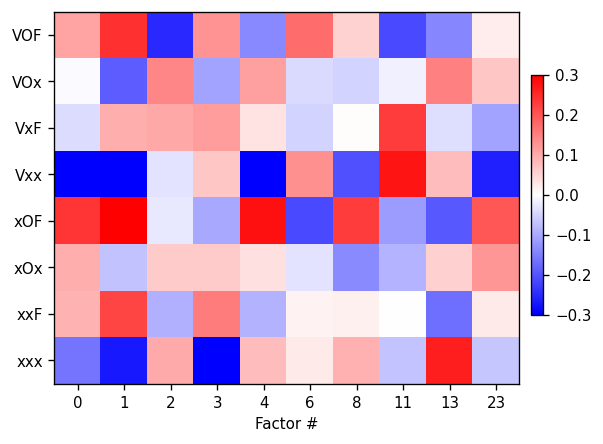

In [31]:
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(r_matrix.values, cmap='bwr', vmin=-.3, vmax=.3)
ax.set_xticks(np.arange(len(r_matrix.columns)))
ax.set_xticklabels(r_matrix.columns)
ax.set_xlabel('Factor #')
ax.set_yticks(np.arange(len(r_matrix.index)))
ax.set_yticklabels(r_matrix.index)
cbaxes = fig.add_axes([0.92,0.3, 0.02, 0.4])
cb = fig.colorbar(im, ax=ax, cax=cbaxes)


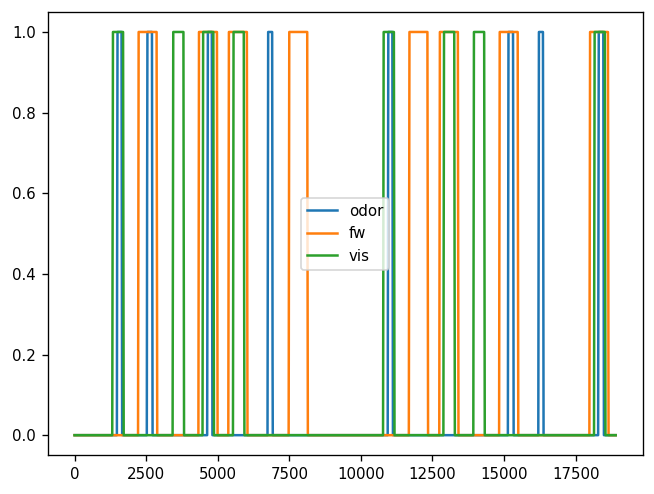

In [32]:
#convert ds[___state_frame] from 1050 frames to 16800 frames due to matlab export code error
complete_nframes = len(ds['trial'])*len(ds['time'])
odor_frames_flat = np.interp(np.linspace(0, len(ds['odor_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['odor_state_frame'])),
                                                   ds['odor_state_frame'])

fw_frames_flat = np.interp(np.linspace(0, len(ds['fw_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['fw_state_frame'])),
                                                   ds['fw_state_frame'])

vis_frames_flat = np.interp(np.linspace(0, len(ds['vis_state_frame'])-1, complete_nframes ),
                                         np.arange(len(ds['vis_state_frame'])),
                                                   ds['vis_state_frame'])


plt.plot(odor_frames_flat, label='odor')
plt.plot(fw_frames_flat, label='fw')
plt.plot(vis_frames_flat, label='vis')
plt.legend()
plt.show()

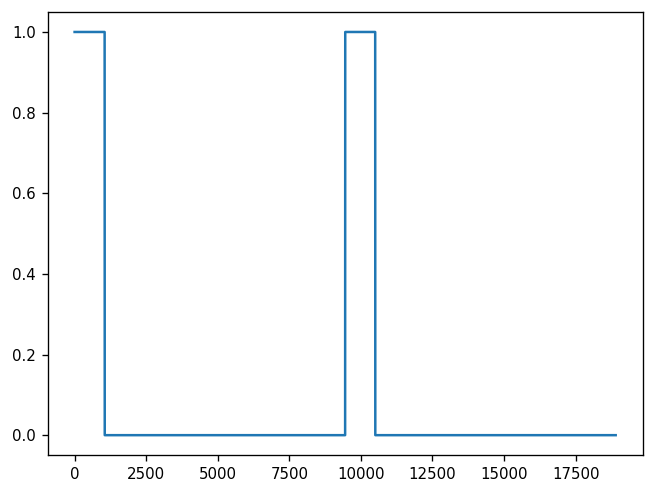

In [33]:
temp_var = np.arange(len(odor_frames_flat))
mask = np.zeros(len(temp_var))
for i in range(len(BASELINE_TRIALS)):
    mask += np.logical_and(temp_var >= BASELINE_TRIALS[i]*len(ds['time']), \
                temp_var < (BASELINE_TRIALS[i]+1)*len(ds['time']))

plt.plot(mask)

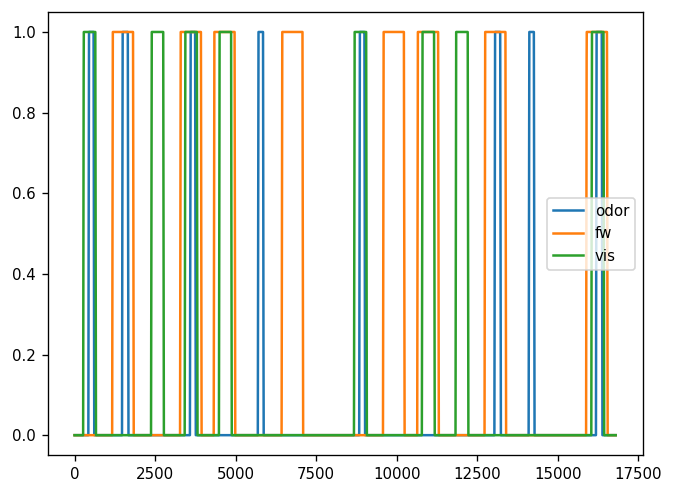

In [34]:
odor_frames_flat = odor_frames_flat[~mask.astype(bool)]
fw_frames_flat = fw_frames_flat[~mask.astype(bool)]
vis_frames_flat = vis_frames_flat[~mask.astype(bool)]
plt.plot(odor_frames_flat, label='odor')
plt.plot(fw_frames_flat, label='fw')
plt.plot(vis_frames_flat, label='vis')
plt.legend()
plt.show()

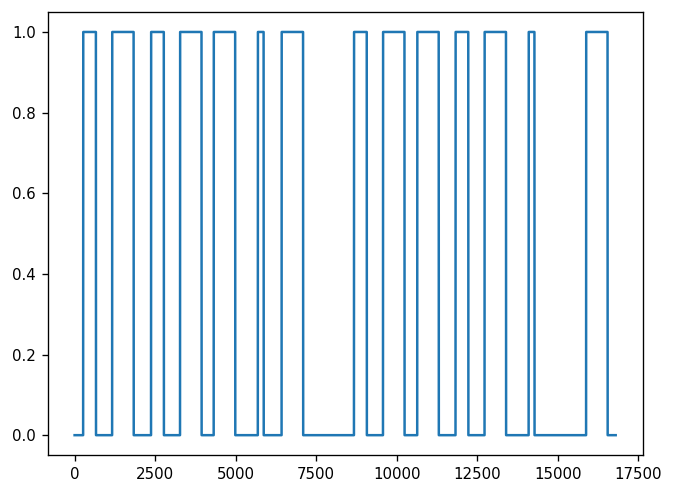

In [35]:
condition_frames = odor_frames_flat + vis_frames_flat + fw_frames_flat

condition_frames[condition_frames > 0] = 1

plt.plot(condition_frames)

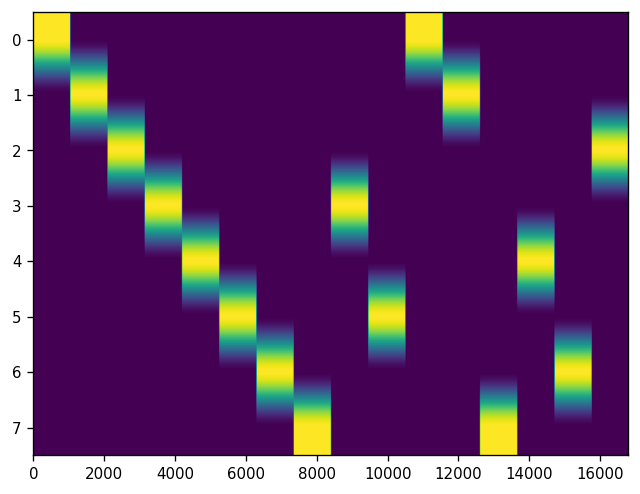

In [36]:
plt.imshow(list(condition_vector.values()), aspect='auto')

## map latents to brain areas

In [38]:
%who_ls

['BASELINE_TRIALS',
 'COND_ORDER',
 'H5_DIR',
 'PCA',
 'Path',
 'StandardScaler',
 'XARRAY_DIR',
 'all_fac',
 'arr',
 'ax',
 'axes',
 'c',
 'cands',
 'cb',
 'cbar_label',
 'cbaxes',
 'cm',
 'colors',
 'complete_nframes',
 'cond',
 'cond_by_ncstem',
 'cond_cmap',
 'condition',
 'condition1',
 'condition2',
 'condition_frames',
 'condition_vector',
 'conditions',
 'conditions_from_xarray',
 'conds',
 'df',
 'dff_vmax',
 'ds',
 'f',
 'f3',
 'fac_var',
 'factor',
 'factors',
 'ff',
 'fig',
 'flat_factor',
 'flies',
 'fly',
 'fly_name',
 'fly_orig_data',
 'fly_recon_data',
 'frac_var',
 'fw_frames_flat',
 'glob',
 'h5_paths',
 'h5py',
 'handles',
 'hi',
 'i',
 'i_condition',
 'i_fac',
 'im',
 'kind',
 'lo',
 'mask',
 'merge_train_valid',
 'n_fac',
 'n_frames_per_trial',
 'n_show',
 'n_trials',
 'name',
 'ncol',
 'np',
 'nrow',
 'num_kept_trials',
 'obs',
 'observed_ts',
 'odor_frames_flat',
 'p',
 'panels',
 'path',
 'pca',
 'pd',
 'pearson_r_p',
 'plt',
 'pred',
 'predicted_ts',
 'r',
 'r2

In [ ]:
f.keys() #gives content of the dataset
# dir(f) gives methods and attributes

<KeysViewHDF5 ['readin_weight', 'readout_bias', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data', 'zscore_mean', 'zscore_std']>

Based on Pandarinath et al. 2018, the readouts are recovered via OLS  
see eqn 36

output_params = Wrate * factors



In [47]:
f['train_output_params']

<HDF5 dataset "train_output_params": shape (12, 1050, 67), type "<f4">

In [48]:
f['valid_output_params']

<HDF5 dataset "valid_output_params": shape (4, 1050, 67), type "<f4">

In [64]:
# extract the readout matrix for each session

# will work with one single file now
# fly = a filename
predicted_ts[fly].shape

#OLS to extract Wrate
factor_fly = factors[fly]
output_params = predicted_ts[fly] 

print(f"factors shape {factor_fly.shape}; output_params shape {output_params.shape}")


factors shape (16, 1050, 50); output_params shape (16, 1050, 67)


In [ ]:
from numpy.linalg import lstsq

def recover_readout_weights(factors, output_params):
    """ extract readout_weight and readout_bias from output_params
    OLS: output_params ~ factors @ W.T + b. Returns W [n_units, n_factors], b [n_units].
    n_units is the # of input regions/components per recording session"""
    n_factors = factors.shape[-1]; n_units = output_params.shape[-1]
    F = factors.reshape(-1, n_factors); O = output_params.reshape(-1, n_units) #reshape to 2D rather than 3D
    F_aug = np.column_stack([F, np.ones(len(F))])
    coef, *_ = lstsq(F_aug, O, rcond=None)
    return coef[:n_factors, :].T, coef[n_factors, :]


In [62]:
Wout, biasout = recover_readout_weights(factor_fly, predicted_ts[fly])

In [78]:
f_bias = f['readout_bias'][()] #extract the values from a h5 dataset
f_bias - biasout

array([-0.03285093, -0.06376785, -0.04894914, -0.04170571, -0.06939964,
       -0.04258377, -0.07649365, -0.08685027, -0.05935981, -0.0638659 ,
       -0.08496005,  0.00857391, -0.07566698, -0.06779541, -0.07453471,
       -0.05846076, -0.04181384,  0.01852773, -0.05774327, -0.00981559,
       -0.05487203, -0.07809689, -0.04442329, -0.060667  , -0.05228883,
       -0.09059781, -0.04803945, -0.08051303, -0.07004576, -0.0335579 ,
       -0.05218577, -0.03236755, -0.05062137, -0.04145875, -0.05165753,
       -0.06581145, -0.07528072,  0.03841861,  0.01432392, -0.01938718,
       -0.07200776, -0.05447936,  0.01068617, -0.03707965, -0.05999476,
        0.01640434, -0.00552297, -0.03020082,  0.02693826,  0.00775856,
       -0.06669003, -0.00724334, -0.00480513,  0.01333605, -0.01345632,
        0.01973058, -0.04321531,  0.03151262, -0.03116418, -0.01142862,
       -0.01392444,  0.01131114, -0.01224558, -0.0259112 , -0.02519765,
       -0.06621727,  0.03892928])

In [79]:
Wout.shape

(67, 50)

### Sanity check: does the OLS-recovered readout match the trained one?

`f['readout_bias']` is *not* the trained bias. It is the PCR alignment bias written by
the data-prep notebook, used only to **initialize** `readout.N.bias`
(`lfads_torch/modules/readin_readout.py`). The readout has `requires_grad=True`, so
training moves it; the h5 copy stays frozen at its epoch-0 value. Because the data were
z-scored, that init is numerically zero (~1e-13), so `f_bias - biasout` is just `-biasout`.

The real ground truth is `readout.N.{weight,bias}` in the checkpoint.

In [ ]:
# --- compare recovered readout against the trained checkpoint ---
import torch

# latest checkpoint in the same run folder (highest epoch)
ckpts = sorted(H5_DIR.glob('checkpoint_epoch=*/*.ckpt'),
               key=lambda p: int(re.search(r'epoch=(\d+)', str(p)).group(1)))
print("using:", ckpts[-1].parent.name)

sd = torch.load(ckpts[-1], map_location='cpu')['state_dict']
i_sess = flies.index(fly)                      # readout.N matches sorted datafile order
W_ck = sd[f'readout.{i_sess}.weight'].numpy()  # (n_reg, n_fac)
b_ck = sd[f'readout.{i_sess}.bias'].numpy()    # (n_reg,)

print(f"OLS vs checkpoint : max|W| diff = {np.abs(Wout - W_ck).max():.2e}, "
      f"max|b| diff = {np.abs(biasout - b_ck).max():.2e}")
print(f"h5 'readout_bias' : max|b| diff = {np.abs(f_bias - b_ck).max():.2e}  "
      f"(PCR init, not trained; |f_bias|max = {np.abs(f_bias).max():.2e})")

### restore to 75 regions

In [91]:
# utils.Xarray_UtilFns lives at the lfads-torch repo root; this notebook runs from
# lfads_on_kcEXP00H/, so add '..' to the path.

sys.path.insert(0, '..')
from utils.Xarray_UtilFns import load_group_xarrays

ds_list = load_group_xarrays(XARRAY_DIR)

# Canonical 75-region order (shared across all flies in the xarray files)
REGION_NAMES = list(ds_list[0].coords['region'].values)
N_REGIONS = len(REGION_NAMES)
FLY_IDS = [ds.attrs['fly_id'] for ds in ds_list]
ds_by_flyid = {ds.attrs['fly_id']: ds for ds in ds_list}

# Each fly's LFADS h5 was trained only on its non-dead regions (data prep drops regions that are
# all-NaN across every trial & timepoint), so per-fly counts are 69-71, NOT 75. Recompute that
# keep-mask here to map each fly's h5 regions back onto canonical 75-region names.
keep_mask_by_flyid = {}
for ds in ds_list:
    arr = ds['deltaF_rg'].values                      # (n_trials, n_time, 75)
    keep_mask_by_flyid[ds.attrs['fly_id']] = ~np.isnan(arr).all(axis=(0, 1))
    nk = int(keep_mask_by_flyid[ds.attrs['fly_id']].sum())
    print(f"  {ds.attrs['fly_id'][-18:]}: {nk}/{N_REGIONS} regions kept")

print(f'\n{N_REGIONS} canonical regions: {REGION_NAMES[:6]}...')

# Regions flagged as likely artifacts (optic-lobe neuropils dominated by the visual stimulus /
# high-variance imaging) — excluded from region RANKINGS (not from the model). Edit as needed.
ARTIFACT_BASES = ['MED', 'AME', 'LO', 'LOP']
# Flagged artifact regions on the canonical frame (base name in ARTIFACT_BASES, both hemispheres)
ARTIFACT_REGIONS = [rn for rn in REGION_NAMES if rn.rsplit('-', 1)[0] in ARTIFACT_BASES]
ARTIFACT_MASK = np.array([rn in ARTIFACT_REGIONS for rn in REGION_NAMES])
print(f'Artifact regions flagged ({len(ARTIFACT_REGIONS)}): {ARTIFACT_REGIONS}')

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Loaded 5 datasets from ../datasets/xarray_files/
  eInterpPerRec_DVAP: 69/75 regions kept
  eInterpPerRec_DVAP: 71/75 regions kept
  eInterpPerRec_DVAP: 71/75 regions kept
  eInterpPerRec_DVAP: 71/75 regions kept
  eInterpPerRec_DVAP: 69/75 regions kept

75 canonical regions: ['AME-R', 'LO-R', 'NO', 'BU-R', 'PB', 'LH-R']...
Artifact regions flagged (8): ['AME-R'

In [93]:
def to_canon(arr, fly_stem, fill=np.nan):
    """Scatter a per-fly (n_reg_fly, ...) array onto the canonical (75, ...) frame."""
    out = np.full((N_REGIONS,) + arr.shape[1:], fill, dtype=float)
    out[canon_idx[fly_stem]] = arr
    return out

In [94]:
Wout_75 = to_canon(Wout, fly)

NameError: name 'canon_idx' is not defined

In [92]:
valid_mask = {}   # fly_stem -> bool (75,) True where region present for this fly
for fly_stem in flies:
    m = np.zeros(N_REGIONS, bool); m[canon_idx[fly_stem]] = True
    valid_mask[fly_stem] = m
    print(f'  {SHORT[fly_stem]}: {int(m.sum())}/{N_REGIONS} regions present')

NameError: name 'canon_idx' is not defined

### use Wrate per session and visualize contributions of each unit (region, component) to each factor
"how much each factor drives each region"

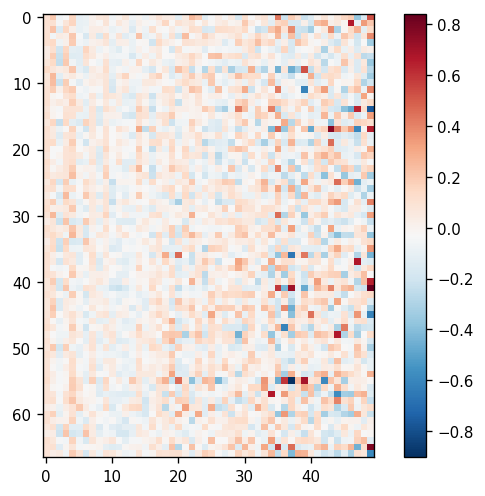

In [84]:
plt.imshow(Wout, cmap='RdBu_r')
plt.colorbar()

## Bridge to notebook 5 — canonical 75-region frame

`Wout` is in this fly's **native** region order (66-67 rows). To label rows, or compare
regions across flies, lift each fly's `W` onto the shared **canonical 75-region** frame,
exactly as `5_region_contributions_kcEXP00H_atle.ipynb` does. `canon_idx[fly]` holds the
indices into the canonical order; absent regions become `NaN`.

**One thing does not carry over unchanged.** Notebook 5 builds `canon_idx` from the
all-NaN rule alone (69-71 regions) and treats the optic-lobe regions as an
*ARTIFACT_MASK* excluded only from rankings. This run's dataset (`KC1pt2`, from
`1.2_data_prep_KC.ipynb` cell 17) instead drops those 8 optic-lobe regions **from the
model itself**, then drops any remaining all-NaN region — giving 67/67/67/66/67. Copying
notebook 5's cell verbatim would assert-fail on the region count. The cell below applies
both steps, and its counts match the h5 files exactly.

In [95]:
# --- canonical 75-region frame (bridge from notebook 5) ---
# The KC1pt2 dataset drops regions in TWO steps (1.2_data_prep_KC.ipynb, cell 17):
#   1. the 8 optic-lobe regions in REGIONS_TO_SKIP, for every fly
#   2. then any region still all-NaN for that fly (here: only PRW, in H36006-007)
# Notebook 5 applies step 2 only (its run used a different dataset), which yields
# 69-71 regions and will NOT line up with the 66-67 in this run's h5 files.
BASELINE_TRIALS = [0, 9]
REGIONS_TO_SKIP = ['AME-R', 'AME-L', 'LO-R', 'LO-L', 'MED-R', 'MED-L', 'LOP-L', 'LOP-R']

REGION_NAMES = None
canon_idx, region_names_fly = {}, {}   # fly -> indices into canonical 75 / their names
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    stem = Path(p).stem
    if stem not in flies:
        continue
    with xr.open_dataset(p) as ds:
        if REGION_NAMES is None:
            REGION_NAMES = [str(r) for r in ds.coords['region'].values]
        ds_c = ds.drop_isel(trial=BASELINE_TRIALS)
        keep = [r for r in ds_c['region'].values if r not in REGIONS_TO_SKIP]
        alive = ~np.isnan(ds_c.sel(region=keep)['deltaF_rg'].values).all(axis=(0, 1))
    region_names_fly[stem] = list(np.asarray(keep)[alive])
    canon_idx[stem] = np.array([REGION_NAMES.index(n) for n in region_names_fly[stem]])

N_REGIONS = len(REGION_NAMES)

valid_mask = {}                        # fly -> bool (75,), True where region present
for fly_ in flies:
    assert len(canon_idx[fly_]) == predicted_ts[fly_].shape[-1], fly_   # must match h5
    m = np.zeros(N_REGIONS, bool); m[canon_idx[fly_]] = True
    valid_mask[fly_] = m
    print(f'  {short[fly_]}: {int(m.sum())}/{N_REGIONS} regions')

def to_canon(arr, fly_, fill=np.nan):
    """Scatter a per-fly (n_reg_fly, ...) array onto the canonical (75, ...) frame."""
    out = np.full((N_REGIONS,) + arr.shape[1:], fill, dtype=float)
    out[canon_idx[fly_]] = arr
    return out

  H30003-005: 67/75 regions
  H34006-007: 67/75 regions
  H35005-006: 67/75 regions
  H36006-007: 66/75 regions
  H37003-004: 67/75 regions


In [101]:
np.abs(readout_weights[fly]).shape

(75, 50)

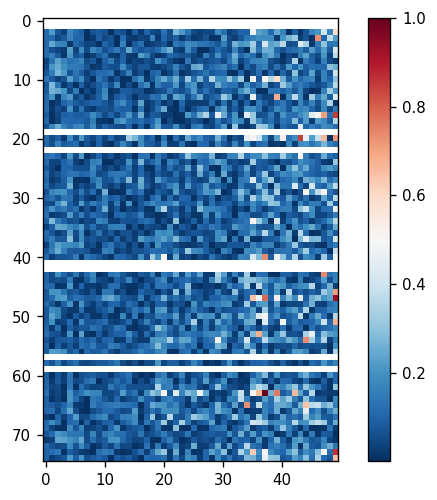

In [111]:
s=fly
aaa=np.abs(readout_weights[s]) /np.nanmax(np.abs(readout_weights[s]))
plt.imshow(aaa,cmap='RdBu_r')
plt.colorbar()

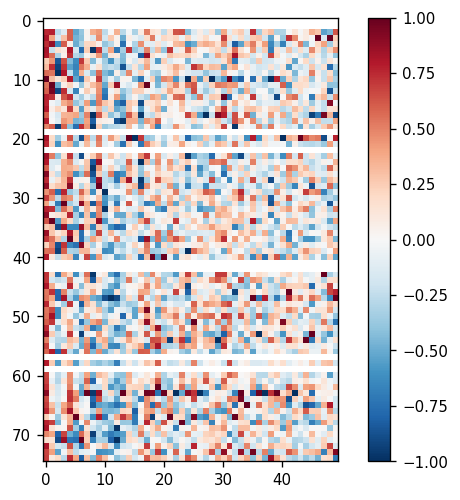

In [124]:
s=fly
bbb=readout_weights[s] /np.nanmax(np.abs(readout_weights[s]), axis = 0)
plt.imshow(bbb,cmap='RdBu_r')
plt.colorbar()

#for now, we stick with relative contributions (so we normalize per column instead of a global max (single value) for the entire matrix)
#but also will look at variance explained by each factor to the ts across experiment and ts per trial conditions


In [120]:
# --- recover the readout for every fly, lifted onto the canonical frame ---
readout_W, readout_b, readout_weights = {}, {}, {}
for fly_ in flies:
    W, b = recover_readout_weights(factors[fly_], predicted_ts[fly_])
    readout_W[fly_], readout_b[fly_] = W, b            # native (n_reg_fly, n_fac)
    readout_weights[fly_] = to_canon(W, fly_)          # canonical (75, n_fac), NaN absent
    print(f'  {short[fly_]}: W {W.shape} -> canon {readout_weights[fly_].shape}')

# cross-fly mean |W|, normalised per factor. Rows absent in EVERY fly (the 8 skipped
# optic-lobe regions) stay NaN rather than going through an empty nanmean.
stack = np.stack([np.abs(readout_weights[s]) /
                  (np.nanmax(np.abs(readout_weights[s]), axis=0, keepdims=True) + 1e-12)
                  for s in flies], 0)                  # (n_flies, 75, n_fac)


  H30003-005: W (67, 50) -> canon (75, 50)
  H34006-007: W (67, 50) -> canon (75, 50)
  H35005-006: W (67, 50) -> canon (75, 50)
  H36006-007: W (66, 50) -> canon (75, 50)
  H37003-004: W (67, 50) -> canon (75, 50)


In [125]:
stack.shape

(5, 75, 50)

In [128]:
stack[0,3,2]

0.16126020738408126

In [129]:
# heatmap overlaid with fly brains per factor, and include as text variance explained

Goal:
1. create a broadly-distributed vs. region-selective score for each factor (factors that drive many brain regions = broadly-distributed)
2. "encoding score" for how each factor encodes sensorimotor contexts and modalities

ex: a factor that encodes walk-only and has a broadly-distributed score etc etc